## Explorando correlações e colinearidade

### Buscando colinearidades

In [ ]:
import pandas as pd

df = pd.read_excel("database/BD_Calorific_Value_PCA.xlsx")
df.describe().loc[["min", "max", "mean"]].T.astype(float).round(2)


In [ ]:
import pandas as pd
import numpy as np

correlacao = df.corr(numeric_only=True)

redundantes = []
for i in range(len(correlacao.columns)):
    for j in range(i + 1, len(correlacao.columns)):
        col1 = correlacao.columns[i]
        col2 = correlacao.columns[j]
        corr_value = correlacao.iloc[i, j]
        if abs(corr_value) > 0.999:
            redundantes.append((col1, col2, corr_value))


for col1, col2, corr in redundantes:
    print(f"{col1} e {col2} têm correlação {corr:.4f}")
    print()

In [ ]:
homo = df["HOMO"].to_numpy()
homo_scalled = (homo - homo.mean()) / homo.std()
homo_scalled.mean(), homo_scalled.std()

In [ ]:
ip = df["Ionization potential (IP)"].to_numpy()
ip_scalled = (ip - ip.mean()) / ip.std()
# ip_scalled.mean(), ip_scalled.std()

In [ ]:
for (h,i) in zip(homo_scalled, ip_scalled):
    print(f"{h:.2f}", f"{i:.2f}")

### Explorando correlações

In [ ]:
df = pd.read_excel("database/BD_Calorific_Value_PCA.xlsx")
work_cols = [
    'Calorific Value (MJ/kg)',
    'HOMO', 'LUMO', 'GAP', 
    'Enthalpy', 'Heat capacity',
    'Chemical potential (CP)', 
    'Softness (S)',
    'Electrophilicity index (EI)',
    'w-', 'w+', 
    'Electron\ntransfer (ET)',
]

correlacao = df[work_cols].corr()

correlations = []
for i in range(len(correlacao.columns)):
    for j in range(i + 1, len(correlacao.columns)):
        col1 = correlacao.columns[i]
        col2 = correlacao.columns[j]
        corr_value = correlacao.iloc[i, j]
        correlations.append({
            "col1": col1,
            "col2": col2,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value)
        })
df_correlations = pd.DataFrame(correlations).sort_values(by="abs_correlation", ascending=False).drop(columns=["abs_correlation"])

In [ ]:
df_correlations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# fig, ax = plt.subplots(figsize=(50,50))

sns.pairplot(df[work_cols], diag_kind="kde")
plt.tight_layout()

plt.show()

## PCA

In [13]:
import pandas as pd
from pca import plot_pca, pca_importances


df = pd.read_excel("database/BD_Calorific_Value_PCA.xlsx")
work_cols = [
    'Calorific Value (MJ/kg)',
    'HOMO', 'LUMO', 'GAP', 
    'Enthalpy', 'Heat capacity',
    'Chemical potential (CP)', 
    'Softness (S)',
    'Electrophilicity index (EI)',
    'w-', 'w+', 
    'Electron\ntransfer (ET)',
]

df = df[work_cols + ["ID Sample", "Class Compounds"]]

### Baixa importancia de 'Calorific Value (MJ/kg)'

In [ ]:
pca, df_pca = plot_pca(
    df,
    hue_col= None,
    label_col="ID Sample",
    non_numeric_columns=["ID Sample", "Class Compounds"],
    figsize=(10,6),
    legend_ncols=2,
    ylims=None,
    xlims=None
    # bbox_to_anchor=[1.1,0]
)

In [ ]:
pca_importances(pca, work_cols, n=12)

#### Sua variância absoluta é baixa?

In [ ]:
df[work_cols].var()

# é mais difícil de prever com precisão — pequenos erros têm peso grande no R2

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
sns.violinplot(df['Calorific Value (MJ/kg)'], ax=ax)#,cut=0,scale="count", inner="quartile")
print(ax.get_xlim())
print(ax.get_ylim())
plt.show()

In [ ]:
for group_name, df_group in df.groupby("Class Compounds"):
    fig, ax = plt.subplots(figsize=(5, 4))

    sns.violinplot(df_group['Calorific Value (MJ/kg)'], ax=ax)
    ax.set_ylim(-3.157314807071713, 94.4573695107338)
    ax.set_title(group_name)
    plt.show()


In [ ]:
df["Class Compounds"].value_counts()

#### Não varia junto com outras variáveis?

In [ ]:
df[work_cols].corr()["Calorific Value (MJ/kg)"].drop("Calorific Value (MJ/kg)")

# Se a variável alvo (Calorific Value) é independente das outras variáveis, então os modelos realmente não conseguem aprender nada útil com os preditores (regressão fraca)
# Ser independente significa ser ortognal das principais direção de variação dos dados

### Destacando features no PCA

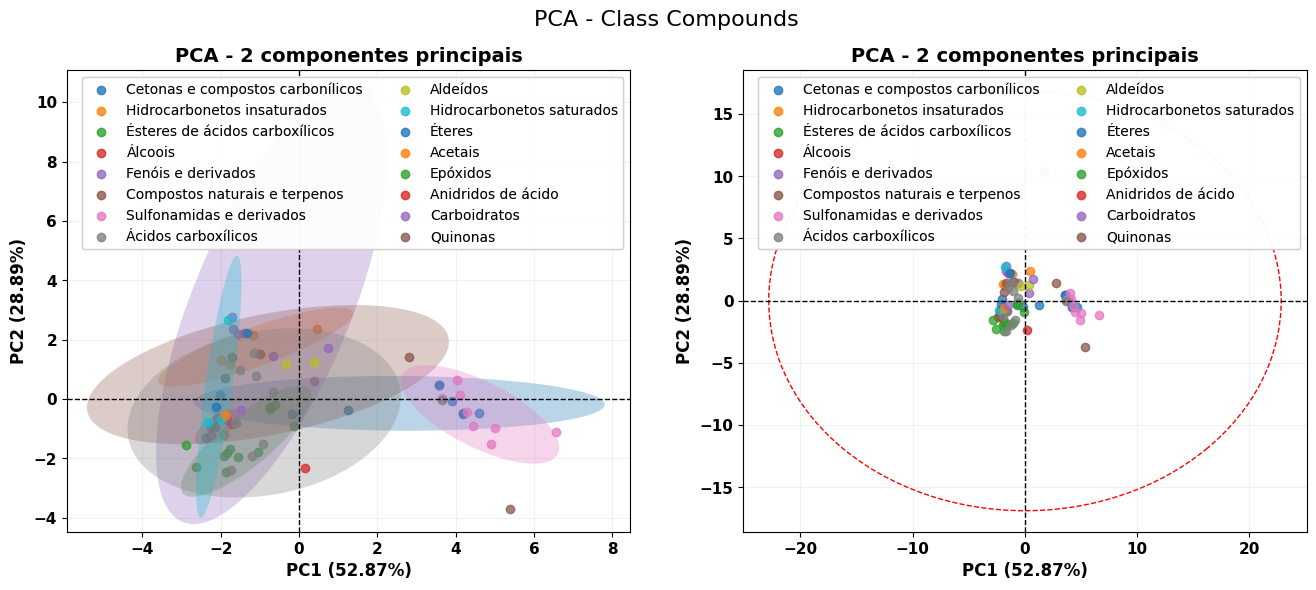

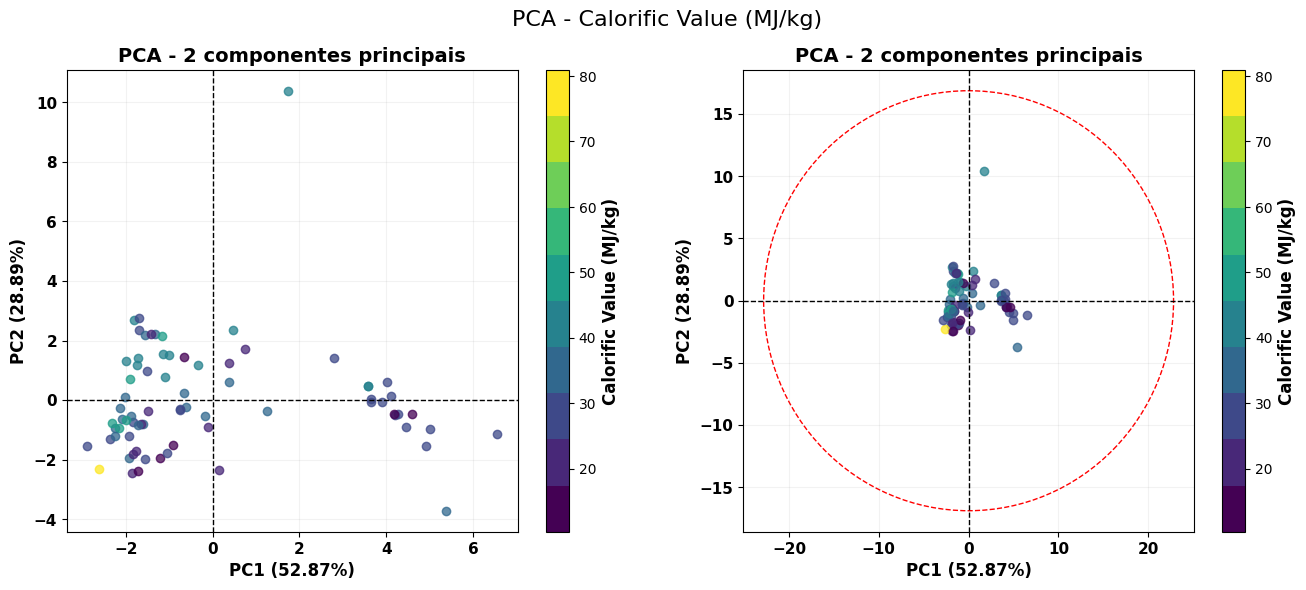

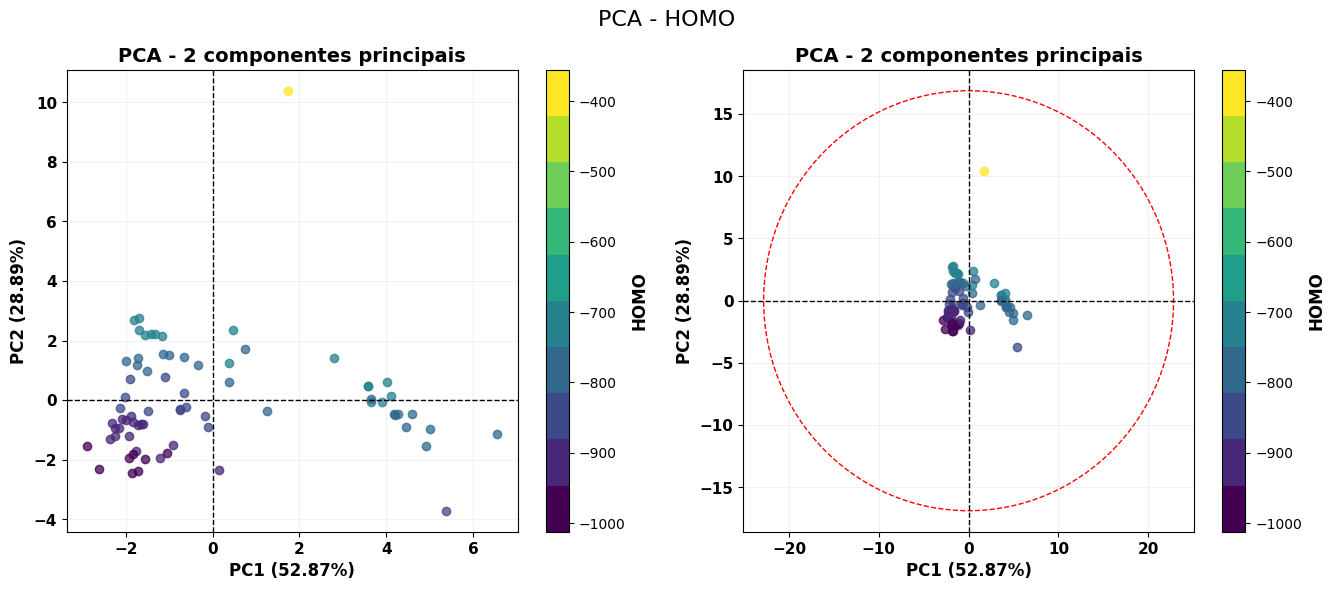

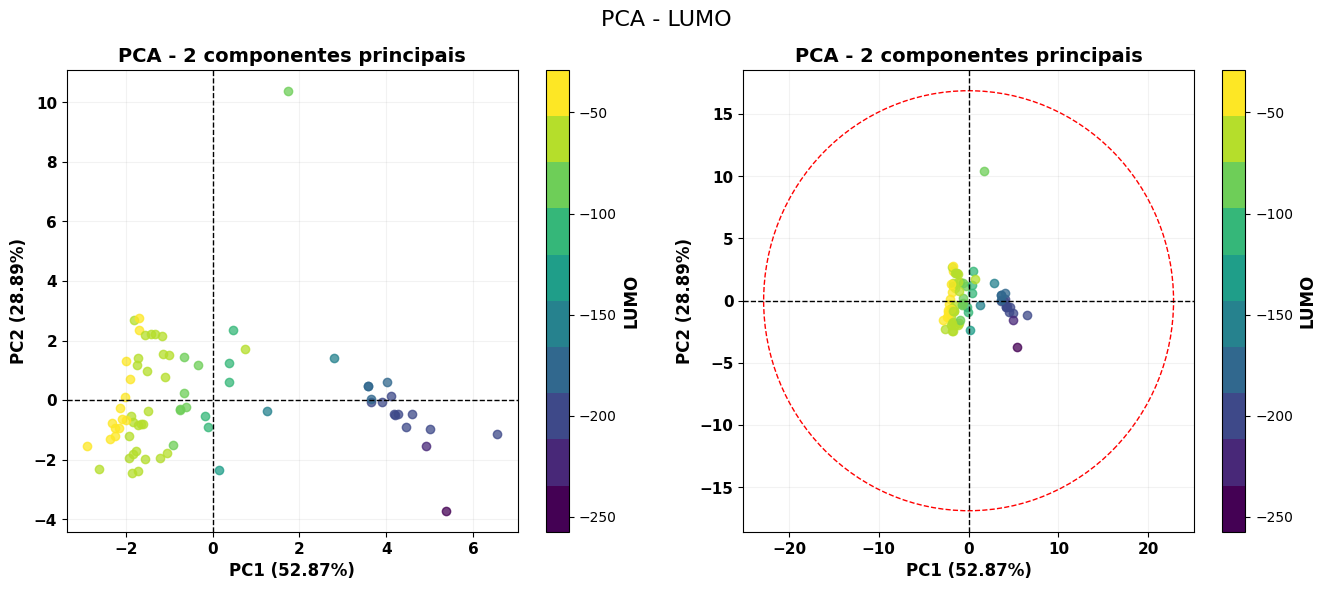

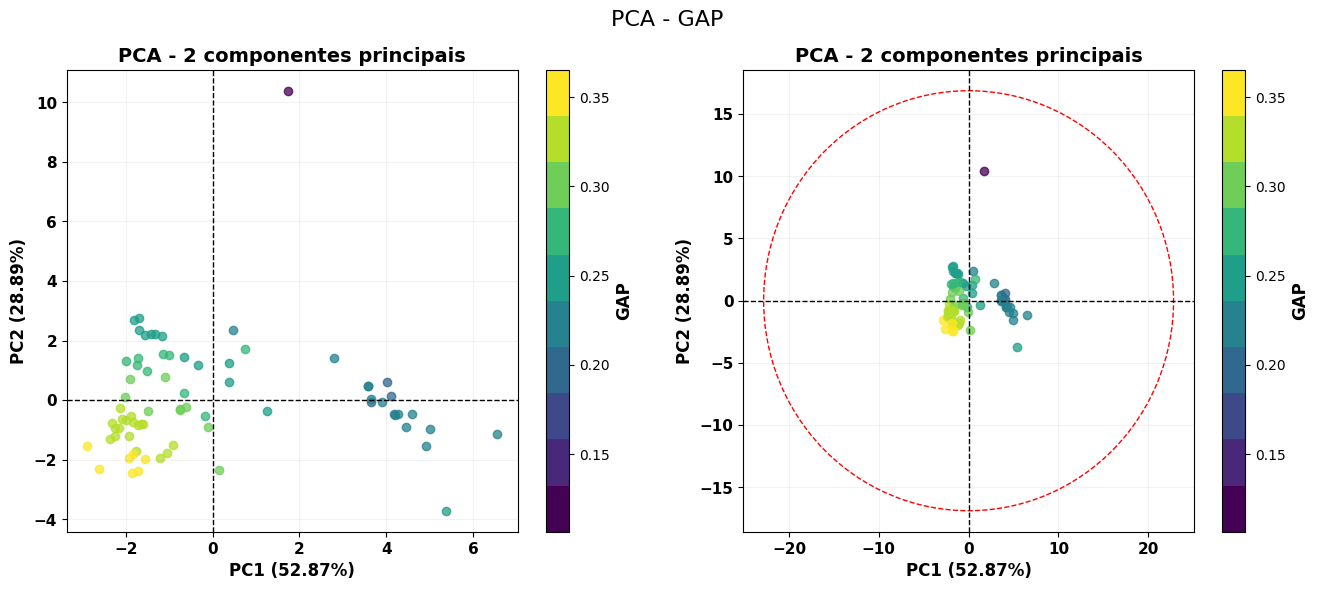

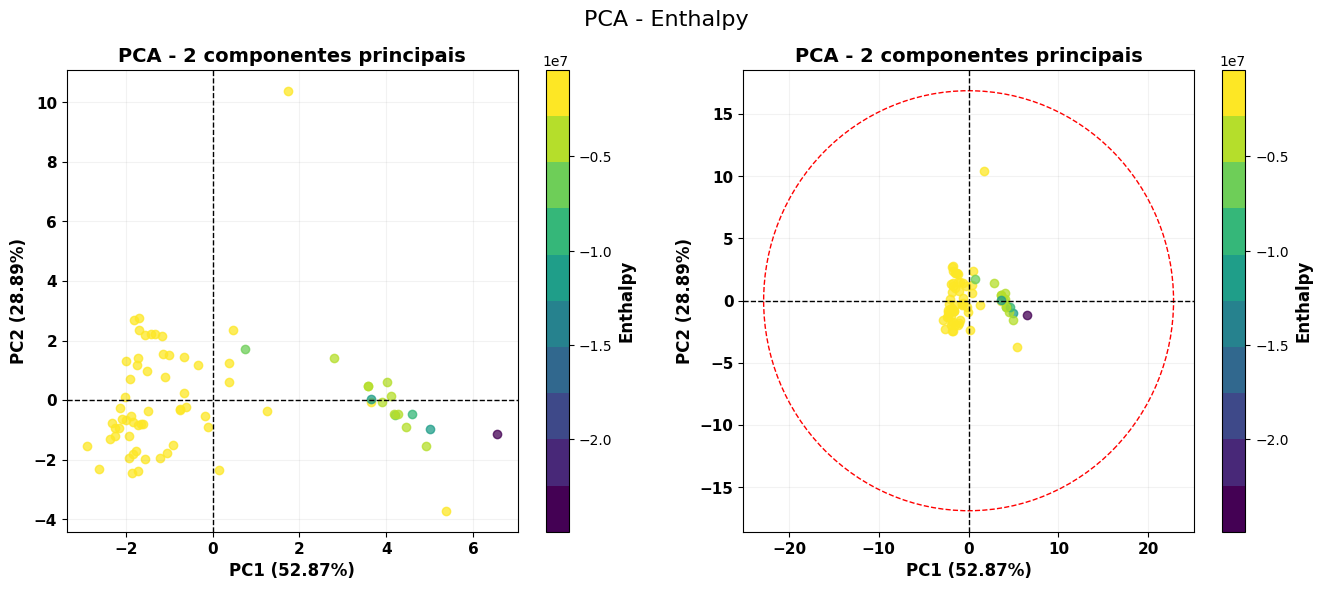

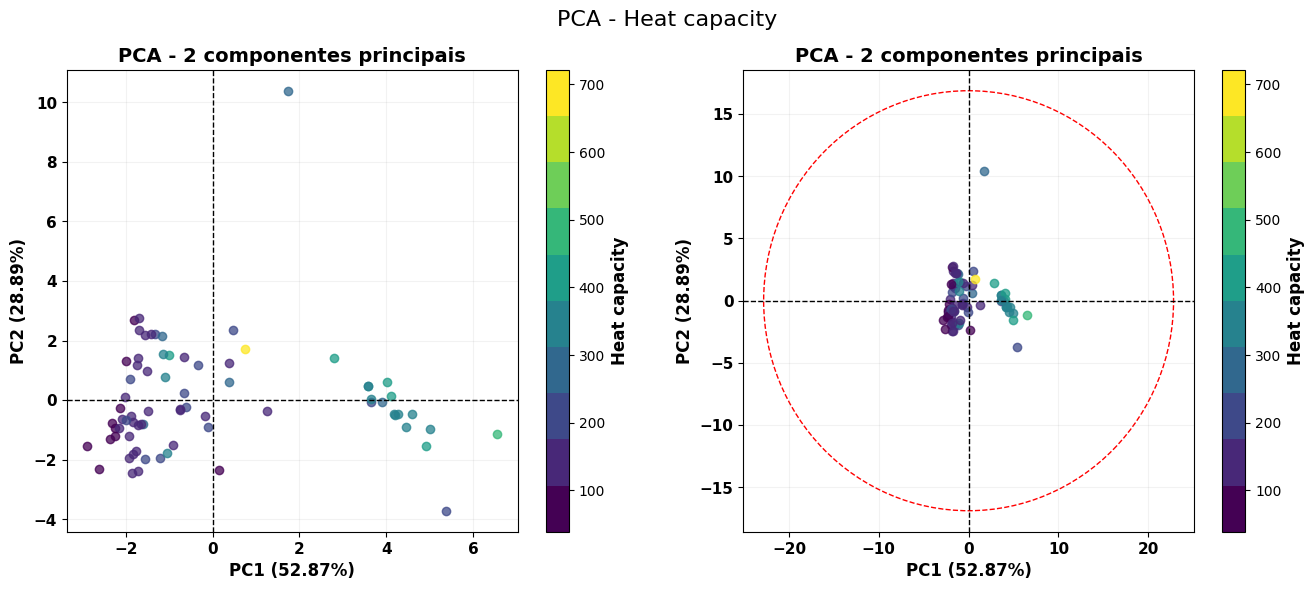

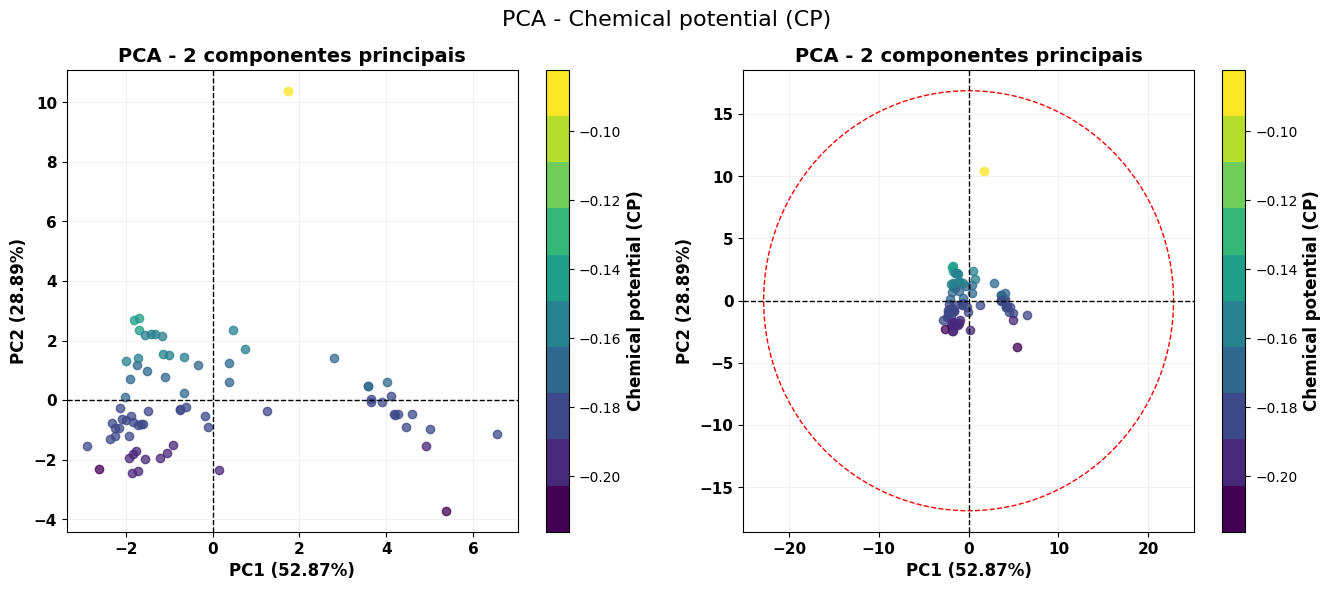

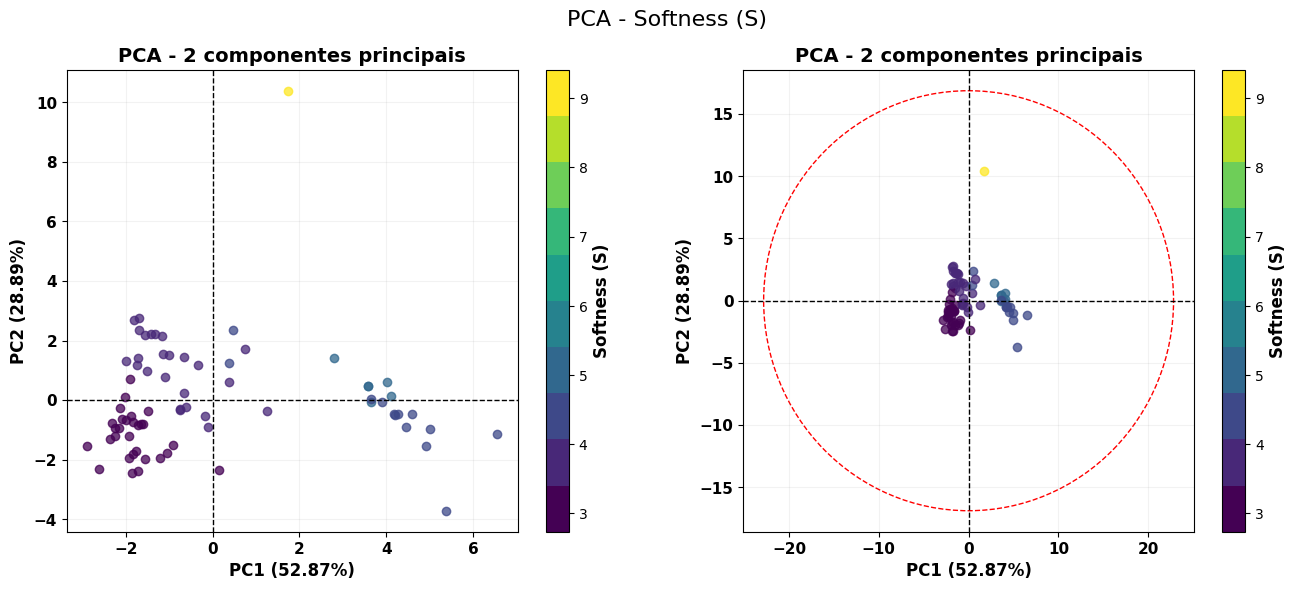

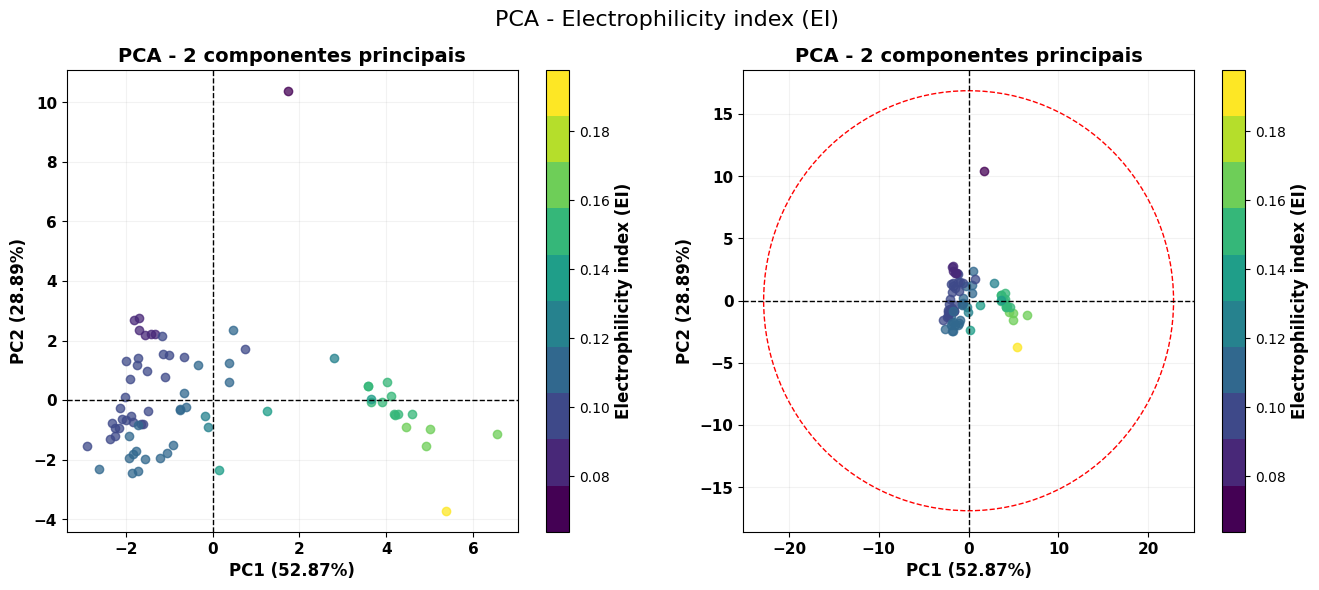

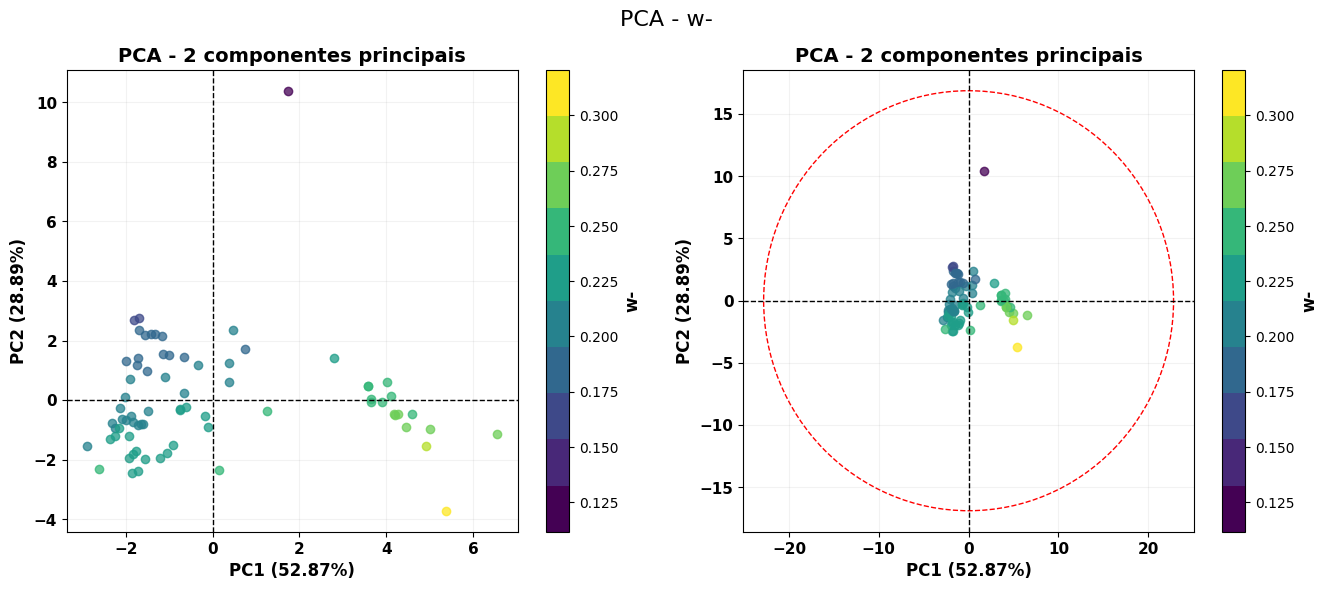

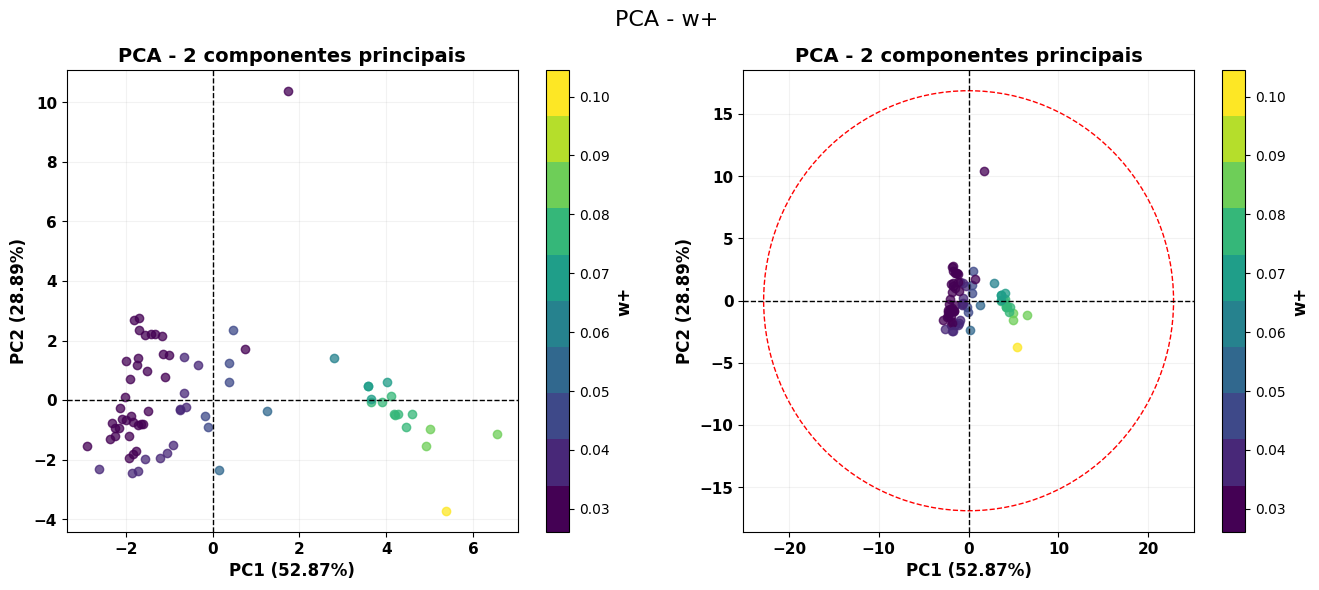

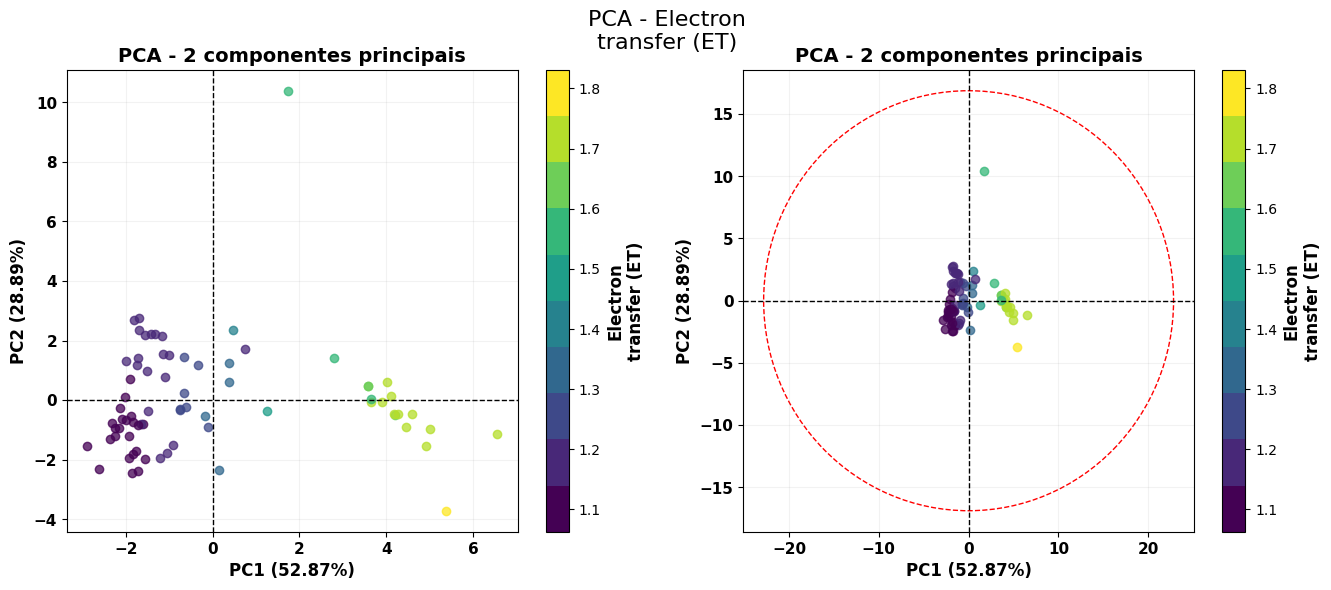

In [14]:
# df = df[df["Class Compounds"] != "Sulfonamidas e derivados"]
# df = df[df["Class Compounds"] != "Cetonas e compostos carbonílicos"]
# df = df[df["Class Compounds"] != "Fenóis e derivados"]

for feature in ["Class Compounds"] + work_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16,6))

    pca, df_pca = plot_pca(
        df,
        hue_col= feature,
        label_col="ID Sample",
        non_numeric_columns=["ID Sample", "Class Compounds"],
        figsize=(10,6),
        legend_ncols=2,
        ylims=None,
        xlims=None,
        ax=axes[0],
        show=False
    )


    pca, df_pca = plot_pca(
        df,
        hue_col= feature,
        label_col="ID Sample",
        non_numeric_columns=["ID Sample", "Class Compounds"],
        figsize=(10,6),
        draw_ellipse=False,
        draw_ellipse_all_data=True,
        ylims=None,
        xlims=None,
        legend_ncols=2,
        ax=axes[1],
        show=False
    )
    ## Titulo da figura
    fig.suptitle(f"PCA - {feature}", fontsize=16)
    plt.show()